Import Libraries

In [ ]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

Extract Dataset

In [ ]:
zip_path = "archive (21).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


Dataset Path

In [ ]:
dataset_path = "dataset/brain_tumor_dataset"

Check Class Distribution

In [ ]:
yes_count = len(os.listdir(os.path.join(dataset_path, "yes")))
no_count = len(os.listdir(os.path.join(dataset_path, "no")))

print("Tumor Images :", yes_count)
print("No Tumor Images :", no_count)

Tumor Images : 155
No Tumor Images : 98


Display sample Images

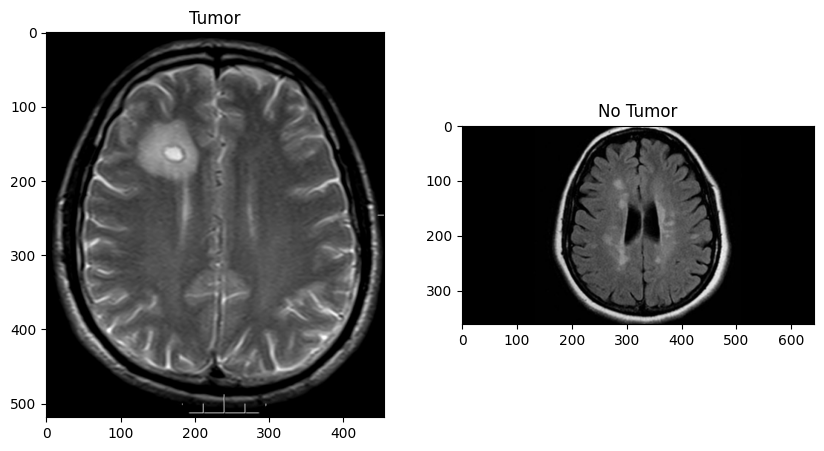

In [ ]:
import cv2

plt.figure(figsize=(10,5))

tumor_img = os.listdir(os.path.join(dataset_path,"yes"))[0]
normal_img = os.listdir(os.path.join(dataset_path,"no"))[0]

img1 = cv2.imread(os.path.join(dataset_path,"yes",tumor_img))
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)

img2 = cv2.imread(os.path.join(dataset_path,"no",normal_img))
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

plt.subplot(1,2,1)
plt.imshow(img1)
plt.title("Tumor")

plt.subplot(1,2,2)
plt.imshow(img2)
plt.title("No Tumor")

plt.show()

Create Train & Validation Data

In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


TensorFlow automatically divided the dataset into:

80% Training Data

20% Validation Data

Check Labels

In [ ]:
print(train_data.class_indices)

{'no': 0, 'yes': 1}


Build CNN Model

In [ ]:
model = Sequential()

# Layer 1
model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

# Layer 2
model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

# Layer 3
model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten
model.add(Flatten())

# Dense Layers
model.add(Dense(128, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model Summary

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Compile Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Early Stopping

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

Train Model

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 926ms/step - accuracy: 0.6404 - loss: 0.6505 - val_accuracy: 0.7400 - val_loss: 0.5400
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.7833 - loss: 0.5100 - val_accuracy: 0.7600 - val_loss: 0.6391
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 852ms/step - accuracy: 0.8128 - loss: 0.5007 - val_accuracy: 0.7600 - val_loss: 0.5239
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.8473 - loss: 0.4210 - val_accuracy: 0.7600 - val_loss: 0.5927
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 828ms/step - accuracy: 0.8522 - loss: 0.3589 - val_accuracy: 0.7000 - val_loss: 0.6062
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.8571 - loss: 0.3652 - val_accuracy: 0.8000 - val_loss: 0.6330


Evaluate Model

In [ ]:
loss, accuracy = model.evaluate(val_data)

print("Validation Accuracy :", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 247ms/step - accuracy: 0.7600 - loss: 0.5239
Validation Accuracy : 0.7599999904632568


Plot Accuracy

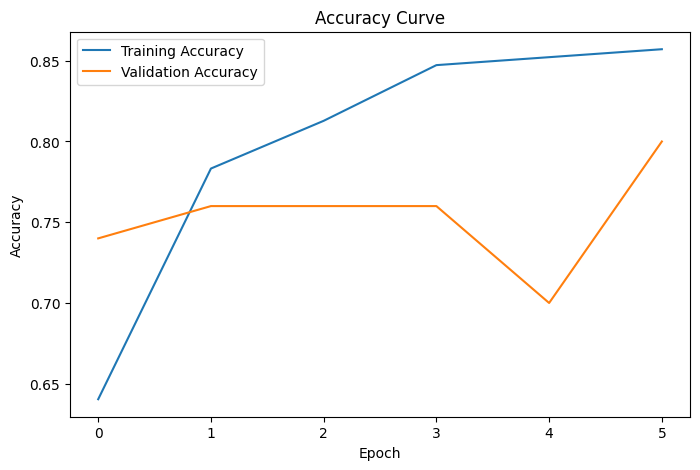

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Training Accuracy",
    "Validation Accuracy"
])

plt.show()

Plot Loss

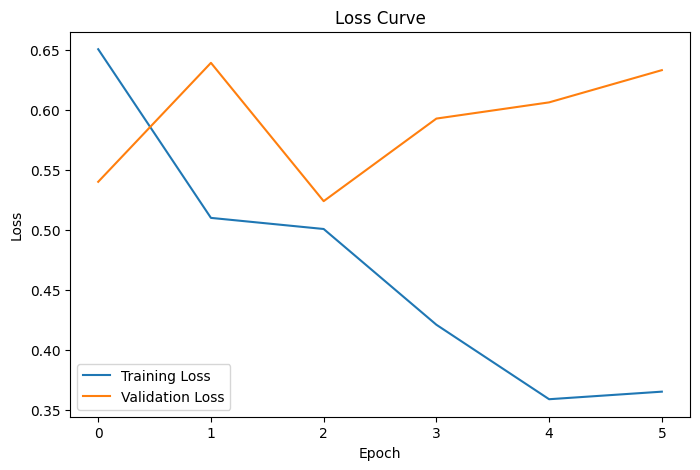

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Training Loss",
    "Validation Loss"
])

plt.show()

Save Model

In [ ]:
model.save("brain_tumor_cnn.h5")

print("Model Saved")

Model Saved


Predict on New MRI Image

In [ ]:
from tensorflow.keras.preprocessing import image

img_path = "/content/test no tumour.jpg"

img = image.load_img(
    img_path,
    target_size=(128,128)
)

img_array = image.img_to_array(img)

img_array = img_array/255.0

img_array = np.expand_dims(
    img_array,
    axis=0
)

prediction = model.predict(img_array)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
[[0.47089747]]


In [ ]:
if prediction[0][0] > 0.5:
    print("Brain Tumor Detected")
else:
    print("No Brain Tumor")

No Brain Tumor


In Machine learning

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.utils import to_categorical

In [ ]:
dataset_path = "dataset/brain_tumor_dataset"

images = []
labels = []

In [ ]:
tumor_folder = os.path.join(dataset_path,"yes")

for img_name in os.listdir(tumor_folder):

    img_path = os.path.join(
        tumor_folder,
        img_name
    )

    img = cv2.imread(img_path)

    img = cv2.resize(
        img,
        (128,128)
    )

    images.append(img)
    labels.append(1)

In [ ]:
normal_folder = os.path.join(dataset_path,"no")

for img_name in os.listdir(normal_folder):

    img_path = os.path.join(
        normal_folder,
        img_name
    )

    img = cv2.imread(img_path)

    img = cv2.resize(
        img,
        (128,128)
    )

    images.append(img)
    labels.append(0)

In [ ]:
X = np.array(images)

y = np.array(labels)

print(X.shape)
print(y.shape)

(253, 128, 128, 3)
(253,)


In [ ]:
X = X / 255.0

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
X_train_ml = X_train.reshape(
    X_train.shape[0],
    -1
)

X_test_ml = X_test.reshape(
    X_test.shape[0],
    -1
)

print(X_train_ml.shape)

(202, 49152)


In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train_ml,
    y_train
)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_ml = rf.predict(
    X_test_ml
)

In [ ]:
ml_accuracy = accuracy_score(
    y_test,
    y_pred_ml
)

print(
    "Machine Learning Accuracy:",
    ml_accuracy
)

Machine Learning Accuracy: 0.8235294117647058


In [ ]:
cnn = Sequential()

cnn.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    )
)

cnn.add(
    MaxPooling2D((2,2))
)

cnn.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

cnn.add(
    MaxPooling2D((2,2))
)

cnn.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)

cnn.add(
    MaxPooling2D((2,2))
)

cnn.add(Flatten())

cnn.add(Dense(
    128,
    activation='relu'
))

cnn.add(
    Dropout(0.5)
)

cnn.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = cnn.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32
)

Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.6211 - loss: 0.6816 - val_accuracy: 0.8049 - val_loss: 0.5063
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.7516 - loss: 0.5289 - val_accuracy: 0.8293 - val_loss: 0.4604
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 935ms/step - accuracy: 0.7826 - loss: 0.4891 - val_accuracy: 0.7805 - val_loss: 0.5667
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 740ms/step - accuracy: 0.8199 - loss: 0.4425 - val_accuracy: 0.7805 - val_loss: 0.5937
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 987ms/step - accuracy: 0.8137 - loss: 0.4098 - val_accuracy: 0.7561 - val_loss: 0.5814
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 741ms/step - accuracy: 0.8137 - loss: 0.3431 - val_accuracy: 0.8049 - val_loss: 0.5049
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 954ms/step - accuracy: 0.8820 - loss: 0.3372 - val_accuracy: 0.5366 - val_loss: 1.1637
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 756ms/step - accuracy: 0.8012 - loss: 0.4460 - val_accuracy: 0.8537 - val_loss: 0.41

In [ ]:
loss, dl_accuracy = cnn.evaluate(
    X_test,
    y_test
)

print(
    "Deep Learning Accuracy:",
    dl_accuracy
)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 300ms/step - accuracy: 0.7647 - loss: 0.5461
Deep Learning Accuracy: 0.7647058963775635


In [ ]:
print("\nMODEL COMPARISON")
print("--------------------------")
print("Random Forest :", ml_accuracy)
print("CNN           :", dl_accuracy)


MODEL COMPARISON
--------------------------
Random Forest : 0.8235294117647058
CNN           : 0.7647058963775635


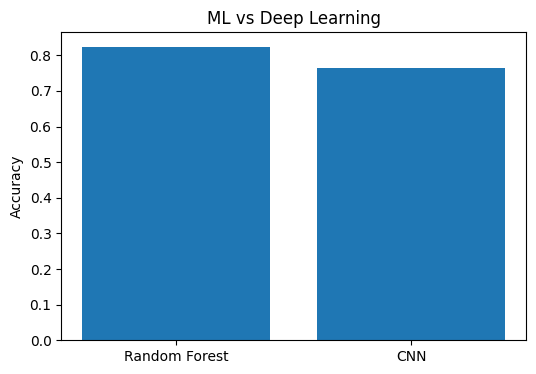

In [ ]:
models = [
    "Random Forest",
    "CNN"
]

scores = [
    ml_accuracy,
    dl_accuracy
]

plt.figure(figsize=(6,4))

plt.bar(
    models,
    scores
)

plt.ylabel("Accuracy")
plt.title("ML vs Deep Learning")

plt.show()